# North Lab, one week

Everything below was computed earlier. This page only puts the questions in order.

| Person | Mon | Tue | Wed | Thu | Fri | Week |
|---|---:|---:|---:|---:|---:|---:|
| Ada | 4 | 5 | 5 | 6 | 7 | 27 |
| Grace | 6 | 6 | 7 | 7 | 8 | 34 |
| Alan | 3 | 4 | 4 | 5 | 4 | 20 |
| Linus | 5 | 5 | 6 | 6 | 7 | 29 |

Daily totals: $18, 20, 22, 24, 26$. Grand total: $110$.

Hours on shift: Ada $30$, Grace $32$, Alan $30$, Linus $31$.


In [1]:
# Rebuild every number the charts will encode.
table = {
    "Ada": [4, 5, 5, 6, 7],
    "Grace": [6, 6, 7, 7, 8],
    "Alan": [3, 4, 4, 5, 4],
    "Linus": [5, 5, 6, 6, 7],
}
weekly = {name: sum(days) for name, days in table.items()}
daily = [sum(table[name][i] for name in table) for i in range(5)]
cells = [value for row in table.values() for value in row]
hours = {"Ada": 30, "Grace": 32, "Alan": 30, "Linus": 31}
assert weekly["Grace"] == 34 and weekly["Alan"] == 20
assert daily == [18, 20, 22, 24, 26]
assert sum(daily) == sum(weekly.values()) == 110
assert max(cells) == 8 and cells.count(8) == 1
assert hours["Ada"] == hours["Alan"]
assert weekly["Ada"] - weekly["Alan"] == 7
print("daily steps", [daily[i + 1] - daily[i] for i in range(4)])
print("busiest cell", max(cells))


daily steps [2, 2, 2, 2]
busiest cell 8


## What changed, who led, and where the hours went

The line says the lab added two jobs a day. The bars say Grace finished $34$ and Alan $20$. The scatter says Alan's shortfall is not explained by a shorter shift: he worked the same $30$ hours as Ada and finished $7$ fewer jobs.


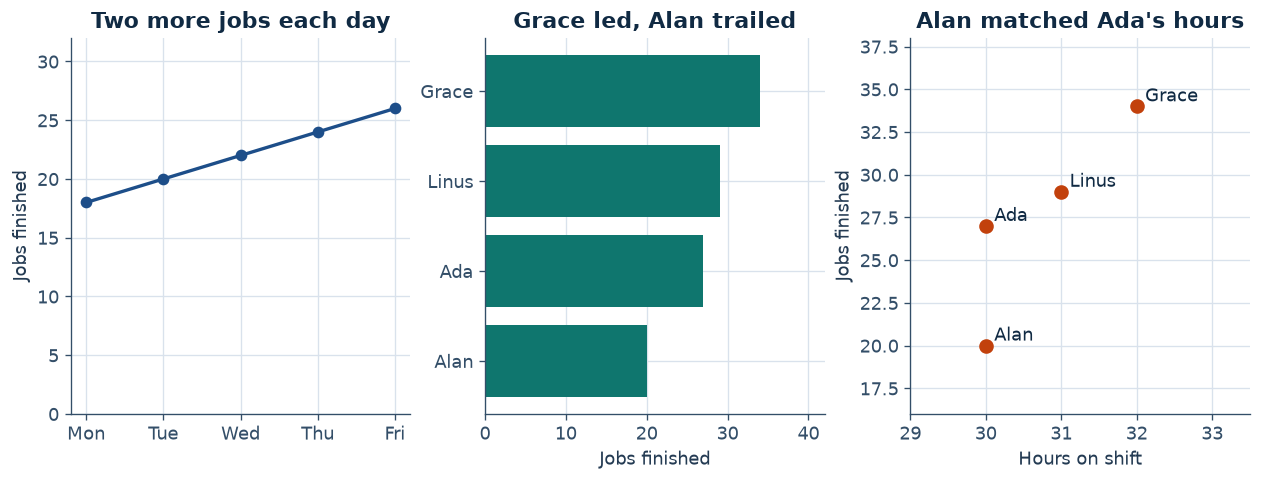

In [2]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Three encodings, three sentences, one study page.
fig, panels = plt.subplots(1, 3, constrained_layout=True, figsize=(10.4, 3.9))
panels[0].plot(["Mon", "Tue", "Wed", "Thu", "Fri"], [18, 20, 22, 24, 26], color=BLUE, marker="o", linewidth=2)
panels[0].set_ylim(0, 32)
panels[0].set_ylabel("Jobs finished")
panels[0].set_title("Two more jobs each day")
panels[1].barh(["Alan", "Ada", "Linus", "Grace"], [20, 27, 29, 34], color=GREEN)
panels[1].set_xlim(0, 42)
panels[1].set_xlabel("Jobs finished")
panels[1].set_title("Grace led, Alan trailed")
names = ["Ada", "Grace", "Alan", "Linus"]
hours = [30, 32, 30, 31]
jobs = [27, 34, 20, 29]
panels[2].scatter(hours, jobs, s=60, color=CLAY, zorder=3)
for name, x, y in zip(names, hours, jobs):
    panels[2].annotate(name, (x, y), textcoords="offset points", xytext=(5, 3), color=INK)
panels[2].set_xlabel("Hours on shift")
panels[2].set_ylabel("Jobs finished")
panels[2].set_xlim(29, 33.5)
panels[2].set_ylim(16, 38)
panels[2].set_title("Alan matched Ada's hours")


## Where in the week the jobs sat

The heatmap keeps the people and the days together. The scale starts at $0$. The printed integers remain, so a color is never the only copy of a count. Grace on Friday is $8$. Alan on Monday is $3$, a light cell, not an empty one.


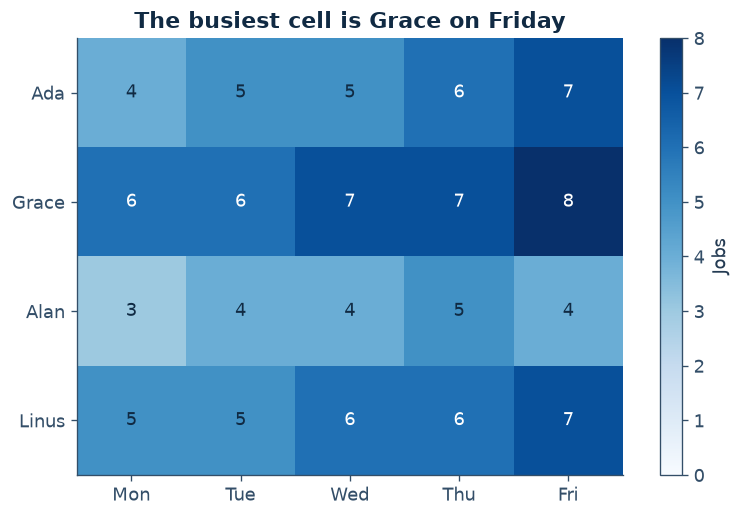

In [3]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# The full grid, labeled, with a zero-based color scale.
jobs = [
    [4, 5, 5, 6, 7],
    [6, 6, 7, 7, 8],
    [3, 4, 4, 5, 4],
    [5, 5, 6, 6, 7],
]
fig, ax = plt.subplots(constrained_layout=True)
image = ax.imshow(jobs, cmap="Blues", vmin=0, vmax=8)
ax.set_xticks(range(5), ["Mon", "Tue", "Wed", "Thu", "Fri"])
ax.set_yticks(range(4), ["Ada", "Grace", "Alan", "Linus"])
ax.grid(False)
for row in range(4):
    for col in range(5):
        ink = "white" if jobs[row][col] >= 6 else INK
        ax.text(col, row, str(jobs[row][col]), ha="center", va="center", color=ink)
fig.colorbar(image, ax=ax).set_label("Jobs")
ax.set_title("The busiest cell is Grace on Friday")
assert jobs[1][4] == 8
assert jobs[2][0] == 3


## What to say about this week

The lab sped up by two jobs a day, from $18$ on Monday to $26$ on Friday. Grace finished $34$ of the $110$ jobs. Alan finished $20$, which is $7$ fewer than Ada despite the same $30$ hours. The single busiest cell was Grace on Friday, with $8$.

That is the whole report. Each sentence has a chart whose marks are those numbers, and each chart has a title that is the sentence rather than the name of the chart type.

## The habit to keep

1. Write one question.
2. Compute the comparison, the step, the bin count, or the cell.
3. Encode it as length, position, or color, on a scale that includes the honest baseline.
4. Title the finding and label the units.
5. Read the sentence back from the picture before you show it to anyone else.
